# 🔧 Optimización con Optuna

**Autor:** [Tu nombre aquí]  
**Fecha:** 2024  
**Objetivo:** Optimizar hiperparámetros de LR y LightGBM usando Optuna

---

## 🎯 ¿Qué vamos a hacer?

Optimizar los 2 modelos baseline usando **Optuna**.

### ⚠️ ¿Por qué NO usamos Cross-Validation?

Hicimos Data Augmentation SOLO en train.
Si usáramos CV, el modelo podría ver comentarios
casi iguales en train y val (data leakage):
Original (train):  "I hate you stupid idiot"
Aumentado (val):   "I hate you foolish idiot" ← casi igual ❌

Por eso usamos val.csv fijo para evaluar Optuna.

---

## 📊 Resultados Baseline (punto de partida)

| Modelo | Accuracy Test | F1 Test | Overfitting | Recall |
|--------|--------------|---------|-------------|--------|
| **Logistic Regression** | 73.3% | 68.3% | 16.5% ⚠️ | 62.3% |
| **LightGBM** | 72.0% | 61.8% | 2.3% ✅ | 49.3% |

### 🎯 Objetivos

- ✅ Overfitting < 5% en ambos modelos
- ✅ Mejorar F1 Test
- ✅ Mejorar Recall (detectar más tóxicos)
- ✅ Registrar en MLFlow para comparar con equipo

---

## 🔬 ¿Cómo funciona Optuna?
Trial 1:  params_1 → evalúa en val.csv → F1: 65%
Trial 2:  params_2 → evalúa en val.csv → F1: 68%
Trial 3:  params_3 → evalúa en val.csv → F1: 71%
...
Trial 50: params_50 → evalúa en val.csv → F1: 75% ✅ MEJOR
↓
Entrenar modelo final con mejores parámetros
↓
Evaluar en TEST.csv (por primera vez)
↓
Registrar en MLFlow

---

## 📂 Datos que usaremos

| Archivo | Filas | Uso |
|---------|-------|-----|
| `train_augmented.csv` | 1,000 | Entrenar modelo |
| `val.csv` | 150 | Optuna evalúa cada trial |
| `test.csv` | 150 | Evaluación final |

---

In [1]:
# Importar librerías
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import optuna
import dagshub

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# LightGBM
import lightgbm as lgb

# Configuración
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("✅ Librerías importadas correctamente")
print(f"\n📦 Versiones:")
print(f"   Optuna:   {optuna.__version__}")
print(f"   LightGBM: {lgb.__version__}")
print(f"   MLFlow:   {mlflow.__version__}")

✅ Librerías importadas correctamente

📦 Versiones:
   Optuna:   4.8.0
   LightGBM: 4.6.0
   MLFlow:   3.12.0


In [60]:
import os
import dagshub
import mlflow

# Cerrar cualquier run abierto
mlflow.end_run()

# Configurar timeout mayor
os.environ['MLFLOW_HTTP_REQUEST_TIMEOUT'] = '120'

# Reiniciar conexión
dagshub.init(
    repo_owner='gemita284',
    repo_name='Project_9_NLP_Team2',
    mlflow=True
)

mlflow.set_experiment("youtube_toxic_comments")
print("✅ Conexión establecida")

Initialized MLflow to track repo "gemita284/Project_9_NLP_Team2"

Repository gemita284/Project_9_NLP_Team2 initialized!

✅ Conexión establecida


In [52]:
# Cargar datos
print("📂 Cargando datos...")
df_train = pd.read_csv('../../data/processed/train_augmented.csv')
df_val   = pd.read_csv('../../data/processed/val.csv')
df_test  = pd.read_csv('../../data/processed/test.csv')

# Separar X e y
X_train = df_train['text_procesado']
y_train = df_train['IsToxic']
X_val   = df_val['text_procesado']
y_val   = df_val['IsToxic']
X_test  = df_test['text_procesado']
y_test  = df_test['IsToxic']

print(f"✅ Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

# Vectorización TF-IDF
print("\n Vectorizando...")
vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec   = vectorizer.transform(X_val)
X_test_vec  = vectorizer.transform(X_test)

print(f"✅ X_train: {X_train_vec.shape}")
print(f"✅ X_val:   {X_val_vec.shape}")
print(f"✅ X_test:  {X_test_vec.shape}")

📂 Cargando datos...
✅ Train: 1,000 | Val: 150 | Test: 150

 Vectorizando...
✅ X_train: (1000, 808)
✅ X_val:   (150, 808)
✅ X_test:  (150, 808)


In [53]:
# OPTUNA - LOGISTIC REGRESSION
print("="*80)
print("🔬 OPTUNA - LOGISTIC REGRESSION")
print("="*80)

def objetivo_lr(trial):
    """
    Función objetivo para Optuna.
    
    Optuna llama esta función en cada trial:
    1. Sugiere parámetros
    2. Entrena LR con esos parámetros
    3. Evalúa en val.csv
    4. Devuelve F1 (Optuna quiere maximizarlo)
    """
    
    # Optuna sugiere parámetros
    C = trial.suggest_float('C', 0.001, 0.05, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'saga'  # Saga funciona con l1 y l2
    max_iter = trial.suggest_int('max_iter', 500, 2000)
    
    # Entrenar LR con esos parámetros
    modelo = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        max_iter=max_iter,
        class_weight='balanced',
        random_state=42
    )
    modelo.fit(X_train_vec, y_train)
    
    # Evaluar en val.csv
    y_pred_val = modelo.predict(X_val_vec)
    f1_val = f1_score(y_val, y_pred_val, average='binary')
    
    return f1_val  # Optuna maximiza este valor

# Crear estudio de Optuna
# direction='maximize' → queremos maximizar F1
study_lr = optuna.create_study(direction='maximize')

print(f"\n⏳ Ejecutando 50 trials...")
print(f"   Cada trial entrena LR y evalúa en val.csv")
print(f"   Optimizando: F1-Score\n")

# Ejecutar optimización
study_lr.optimize(objetivo_lr, n_trials=50)

# Mostrar mejores resultados
print(f"\n{'='*80}")
print(f"✅ OPTIMIZACIÓN COMPLETADA")
print(f"{'='*80}")
print(f"\n🏆 MEJORES PARÁMETROS:")
for param, valor in study_lr.best_params.items():
    print(f"   {param}: {valor}")
print(f"\n🎯 MEJOR F1 en val.csv: {study_lr.best_value:.4f} ({study_lr.best_value*100:.1f}%)")

🔬 OPTUNA - LOGISTIC REGRESSION

⏳ Ejecutando 50 trials...
   Cada trial entrena LR y evalúa en val.csv
   Optimizando: F1-Score


✅ OPTIMIZACIÓN COMPLETADA

🏆 MEJORES PARÁMETROS:
   C: 0.002159022440136803
   penalty: l2
   max_iter: 1347

🎯 MEJOR F1 en val.csv: 0.7310 (73.1%)


In [54]:
# ENTRENAR LR CON MEJORES PARÁMETROS
print("="*80)
print("🤖 ENTRENANDO LR CON MEJORES PARÁMETROS")
print("="*80)

# Extraer mejores parámetros
mejores_params_lr = study_lr.best_params
print(f"\n📋 Parámetros:")
for param, valor in mejores_params_lr.items():
    print(f"   {param}: {valor}")

# Entrenar modelo final
lr_optuna = LogisticRegression(
    C=mejores_params_lr['C'],
    penalty=mejores_params_lr['penalty'],
    solver='saga',
    max_iter=mejores_params_lr['max_iter'],
    class_weight='balanced',
    random_state=42
)

print(f"\n⏳ Entrenando modelo final...")
lr_optuna.fit(X_train_vec, y_train)
print(f"✅ Modelo entrenado correctamente")

# Predicciones
y_pred_train = lr_optuna.predict(X_train_vec)
y_pred_test  = lr_optuna.predict(X_test_vec)
y_proba_test = lr_optuna.predict_proba(X_test_vec)[:, 1]

print(f"\n✅ Predicciones generadas")

🤖 ENTRENANDO LR CON MEJORES PARÁMETROS

📋 Parámetros:
   C: 0.002159022440136803
   penalty: l2
   max_iter: 1347

⏳ Entrenando modelo final...
✅ Modelo entrenado correctamente

✅ Predicciones generadas


In [55]:
# MÉTRICAS LR OPTIMIZADO CON OPTUNA
print("="*80)
print("📊 MÉTRICAS LR OPTIMIZADO CON OPTUNA")
print("="*80)

avg_method = 'binary'

# Calcular métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred_test)
f1_train  = f1_score(y_train, y_pred_train, average=avg_method)
f1_test   = f1_score(y_test, y_pred_test, average=avg_method)

# Mostrar métricas
print(f"\n📊 MÉTRICAS:")
print(f"{'='*40}")
print(f"  Accuracy Train:   {acc_train*100:.1f}%")
print(f"  Accuracy Test:    {acc_test*100:.1f}%")
print(f"  Overfitting Acc:  {(acc_train-acc_test)*100:.1f}%")
print(f"{'='*40}")
print(f"  F1 Train:         {f1_train*100:.1f}%")
print(f"  F1 Test:          {f1_test*100:.1f}%")
print(f"  Overfitting F1:   {(f1_train-f1_test)*100:.1f}%")
print(f"{'='*40}")
print(f"  Precision Test:   {precision_score(y_test, y_pred_test, average=avg_method)*100:.1f}%")
print(f"  Recall Test:      {recall_score(y_test, y_pred_test, average=avg_method)*100:.1f}%")
print(f"  ROC-AUC Test:     {roc_auc_score(y_test, y_proba_test)*100:.1f}%")

# Comparar con baseline
print(f"\n{'='*80}")
print(f"📊 COMPARACIÓN: LR Baseline vs LR Optuna")
print(f"{'='*80}")
print(f"{'Métrica':<20} {'Baseline':>10} {'Optuna':>10} {'Mejora':>10}")
print(f"{'-'*50}")
print(f"{'Accuracy Test':<20} {'73.3%':>10} {acc_test*100:>9.1f}% {(acc_test*100-73.3):>+9.1f}%")
print(f"{'F1 Test':<20} {'68.3%':>10} {f1_test*100:>9.1f}% {(f1_test*100-68.3):>+9.1f}%")
print(f"{'Recall Test':<20} {'62.3%':>10} {recall_score(y_test, y_pred_test, average=avg_method)*100:>9.1f}% {(recall_score(y_test, y_pred_test, average=avg_method)*100-62.3):>+9.1f}%")
print(f"{'Overfitting':<20} {'16.5%':>10} {(acc_train-acc_test)*100:>9.1f}% {((acc_train-acc_test)*100-16.5):>+9.1f}%")

# Verificar overfitting
print(f"\n{'='*40}")
if (acc_train - acc_test) < 0.05:
    print(f"✅ Overfitting CONTROLADO (< 5%)")
else:
    print(f"⚠️ Overfitting ALTO (> 5%)")

# Reporte completo
print(f"\n📋 REPORTE COMPLETO:")
print(classification_report(y_test, y_pred_test,
      target_names=['Normal', 'Tóxico']))

📊 MÉTRICAS LR OPTIMIZADO CON OPTUNA

📊 MÉTRICAS:
  Accuracy Train:   84.4%
  Accuracy Test:    72.7%
  Overfitting Acc:  11.7%
  F1 Train:         85.4%
  F1 Test:          71.3%
  Overfitting F1:   14.1%
  Precision Test:   68.9%
  Recall Test:      73.9%
  ROC-AUC Test:     79.4%

📊 COMPARACIÓN: LR Baseline vs LR Optuna
Métrica                Baseline     Optuna     Mejora
--------------------------------------------------
Accuracy Test             73.3%      72.7%      -0.6%
F1 Test                   68.3%      71.3%      +3.0%
Recall Test               62.3%      73.9%     +11.6%
Overfitting               16.5%      11.7%      -4.8%

⚠️ Overfitting ALTO (> 5%)

📋 REPORTE COMPLETO:
              precision    recall  f1-score   support

      Normal       0.76      0.72      0.74        81
      Tóxico       0.69      0.74      0.71        69

    accuracy                           0.73       150
   macro avg       0.73      0.73      0.73       150
weighted avg       0.73      0.73 

📊 MATRIZ DE CONFUSIÓN - LR OPTUNA


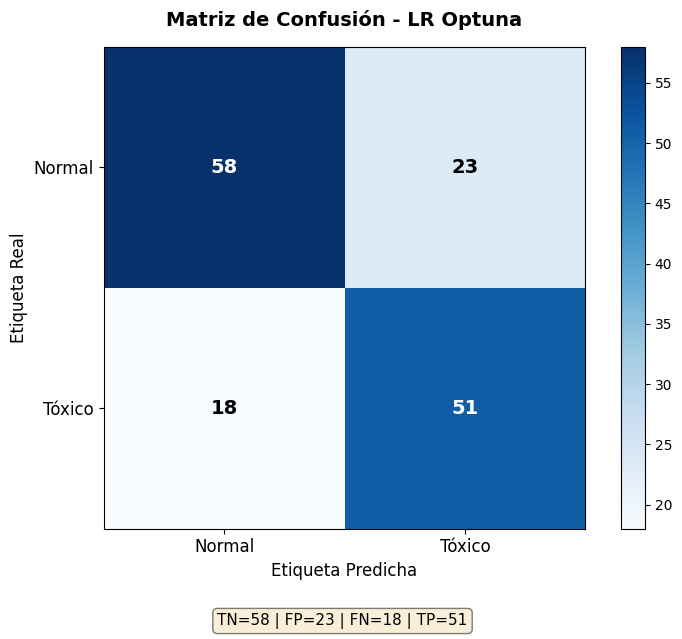


📊 ANÁLISIS MATRIZ:
   ✅ TN: 58 normales bien clasificados
   ✅ TP: 51 tóxicos bien clasificados
   ❌ FP: 23 normales marcados como tóxicos
   ❌ FN: 18 tóxicos que NO detectó

✅ Matriz guardada en: ../../reports/V_02/confusion_matrix_LR_Optuna.png


In [32]:
# MATRIZ DE CONFUSIÓN - LR OPTUNA
print("="*80)
print("📊 MATRIZ DE CONFUSIÓN - LR OPTUNA")
print("="*80)

cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)

clases = ['Normal', 'Tóxico']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(clases, fontsize=12)
ax.set_yticklabels(clases, fontsize=12)

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14, fontweight='bold')

ax.set_title('Matriz de Confusión - LR Optuna',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Etiqueta Real', fontsize=12)
ax.set_xlabel('Etiqueta Predicha', fontsize=12)

plt.figtext(0.5, -0.05,
            f'TN={tn} | FP={fp} | FN={fn} | TP={tp}',
            ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

os.makedirs('../../reports/V_02', exist_ok=True)
ruta_cm_lr_optuna = '../../reports/V_02/confusion_matrix_LR_Optuna.png'
plt.savefig(ruta_cm_lr_optuna, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 ANÁLISIS MATRIZ:")
print(f"   ✅ TN: {tn} normales bien clasificados")
print(f"   ✅ TP: {tp} tóxicos bien clasificados")
print(f"   ❌ FP: {fp} normales marcados como tóxicos")
print(f"   ❌ FN: {fn} tóxicos que NO detectó")
print(f"\n✅ Matriz guardada en: {ruta_cm_lr_optuna}")

In [34]:
# REGISTRAR LR OPTUNA EN MLFLOW
print("="*80)
print("📡 REGISTRANDO LR OPTUNA EN MLFLOW")
print("="*80)

with mlflow.start_run(run_name="LogisticRegression_Optuna_vectorizer_800"):

    # Parámetros del modelo
    mlflow.log_param("modelo", "LogisticRegression")
    mlflow.log_param("C", mejores_params_lr['C'])
    mlflow.log_param("penalty", mejores_params_lr['penalty'])
    mlflow.log_param("solver", "saga")
    mlflow.log_param("max_iter", mejores_params_lr['max_iter'])
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("optuna_trials", 50)

    # Parámetros del vectorizador
    mlflow.log_param("vectorizer", "TF-IDF")
    mlflow.log_param("max_features", 3000)
    mlflow.log_param("ngram_range", "(1,2)")
    mlflow.log_param("min_df", 3)
    mlflow.log_param("max_df", 0.85)

    # ✅ Métricas con convención del equipo
    mlflow.log_metrics({
        "accuracy_train":  acc_train,
        "accuracy_test":   acc_test,
        "f1_train":        f1_train,
        "f1_test":         f1_test,
        "precision_test":  precision_score(y_test, y_pred_test, average=avg_method),
        "recall_test":     recall_score(y_test, y_pred_test, average=avg_method),
        "roc_auc_test":    roc_auc_score(y_test, y_proba_test),
        "overfitting_acc": acc_train - acc_test,
        "overfitting_f1":  f1_train - f1_test
    })

    # Tags
    mlflow.set_tag("developer", "Gema")
    mlflow.set_tag("model_type", "optuna")
    mlflow.set_tag("vectorizer", "TF-IDF")

    # Subir matriz de confusión como artefacto
    mlflow.log_artifact(ruta_cm_lr_optuna)

    # Guardar modelo
    mlflow.sklearn.log_model(lr_optuna, "logistic_regression_optuna_model")

    print(f"\n✅ Métricas registradas con convención del equipo")
    print(f"✅ Matriz de confusión subida como artefacto")
    print(f"✅ Modelo guardado")
    print(f"\n📊 RESUMEN REGISTRADO:")
    print(f"   accuracy_train:  {acc_train*100:.1f}%")
    print(f"   accuracy_test:   {acc_test*100:.1f}%")
    print(f"   f1_train:        {f1_train*100:.1f}%")
    print(f"   f1_test:         {f1_test*100:.1f}%")
    print(f"   precision_test:  {precision_score(y_test, y_pred_test, average=avg_method)*100:.1f}%")
    print(f"   recall_test:     {recall_score(y_test, y_pred_test, average=avg_method)*100:.1f}%")
    print(f"   roc_auc_test:    {roc_auc_score(y_test, y_proba_test)*100:.1f}%")
    print(f"   overfitting_acc: {(acc_train-acc_test)*100:.1f}%")
    print(f"   overfitting_f1:  {(f1_train-f1_test)*100:.1f}%")
    print(f"\n🔗 Ver en DagsHub:")
    print(f"   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow")

📡 REGISTRANDO LR OPTUNA EN MLFLOW


2026/05/13 21:18:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 21:19:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/13 21:19:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



✅ Métricas registradas con convención del equipo
✅ Matriz de confusión subida como artefacto
✅ Modelo guardado

📊 RESUMEN REGISTRADO:
   accuracy_train:  84.4%
   accuracy_test:   72.7%
   f1_train:        85.4%
   f1_test:         71.3%
   precision_test:  68.9%
   recall_test:     73.9%
   roc_auc_test:    79.5%
   overfitting_acc: 11.7%
   overfitting_f1:  14.1%

🔗 Ver en DagsHub:
   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow
🏃 View run LogisticRegression_Optuna_vectorizer_800 at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0/runs/ee9bd43a83cc48e3ac7cf529d94f0857
🧪 View experiment at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0


In [42]:
# OPTUNA - LIGHTGBM + EARLY STOPPING (VERSIÓN FINAL)
print("="*80)
print("🔬 OPTUNA - LIGHTGBM + EARLY STOPPING")
print("="*80)

def objetivo_lgbm(trial):

    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 300), # Bajamos un poco el tope
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True), # Aprendizaje más lento
        'num_leaves':        trial.suggest_int('num_leaves', 10, 31), # Menos hojas
        'max_depth':         trial.suggest_int('max_depth', 2, 5),    # ¡El cambio clave: árboles bajitos!
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 50), # Obligamos a agrupar más datos
        'subsample':         trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'class_weight':      'balanced',
        'random_state':      42,
        'verbose':           -1
    }

    modelo = lgb.LGBMClassifier(**params)

    modelo.fit(
        X_train_vec, y_train,
        eval_set=[(X_val_vec, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=20, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    y_pred_val = modelo.predict(X_val_vec)
    f1_val = f1_score(y_val, y_pred_val, average='binary')

    return f1_val

# Crear estudio
study_lgbm = optuna.create_study(direction='maximize')

print(f"\n⏳ Ejecutando 50 trials...")
print(f"   Optimizando: F1-Score en val.csv\n")

study_lgbm.optimize(objetivo_lgbm, n_trials=50)

print(f"\n{'='*80}")
print(f"✅ OPTIMIZACIÓN COMPLETADA")
print(f"{'='*80}")
print(f"\n🏆 MEJORES PARÁMETROS:")
for param, valor in study_lgbm.best_params.items():
    print(f"   {param}: {valor}")
print(f"\n🎯 MEJOR F1 en val.csv: {study_lgbm.best_value:.4f} ({study_lgbm.best_value*100:.1f}%)")

🔬 OPTUNA - LIGHTGBM + EARLY STOPPING

⏳ Ejecutando 50 trials...
   Optimizando: F1-Score en val.csv


✅ OPTIMIZACIÓN COMPLETADA

🏆 MEJORES PARÁMETROS:
   n_estimators: 217
   learning_rate: 0.032106922359878165
   num_leaves: 15
   max_depth: 5
   min_child_samples: 22
   subsample: 0.848758371189726
   colsample_bytree: 0.879677211423607

🎯 MEJOR F1 en val.csv: 0.5536 (55.4%)


In [43]:
# ENTRENAR LGBM CON MEJORES PARÁMETROS
print("="*80)
print("🤖 ENTRENANDO LGBM CON MEJORES PARÁMETROS")
print("="*80)

# Extraer mejores parámetros
mejores_params_lgbm = study_lgbm.best_params
print(f"\n📋 Parámetros:")
for param, valor in mejores_params_lgbm.items():
    print(f"   {param}: {valor}")

# Entrenar modelo final
lgbm_optuna = lgb.LGBMClassifier(
    n_estimators=mejores_params_lgbm['n_estimators'],
    learning_rate=mejores_params_lgbm['learning_rate'],
    num_leaves=mejores_params_lgbm['num_leaves'],
    max_depth=mejores_params_lgbm['max_depth'],
    min_child_samples=mejores_params_lgbm['min_child_samples'],
    subsample=mejores_params_lgbm['subsample'],
    colsample_bytree=mejores_params_lgbm['colsample_bytree'],
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

print(f"\n⏳ Entrenando modelo final...")
lgbm_optuna.fit(
    X_train_vec, y_train,
    eval_set=[(X_val_vec, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)
print(f"✅ Modelo entrenado correctamente")

# Predicciones
y_pred_train = lgbm_optuna.predict(X_train_vec)
y_pred_test  = lgbm_optuna.predict(X_test_vec)
y_proba_test = lgbm_optuna.predict_proba(X_test_vec)[:, 1]

print(f"\n✅ Predicciones generadas")

🤖 ENTRENANDO LGBM CON MEJORES PARÁMETROS

📋 Parámetros:
   n_estimators: 217
   learning_rate: 0.032106922359878165
   num_leaves: 15
   max_depth: 5
   min_child_samples: 22
   subsample: 0.848758371189726
   colsample_bytree: 0.879677211423607

⏳ Entrenando modelo final...
✅ Modelo entrenado correctamente

✅ Predicciones generadas


In [44]:
# MÉTRICAS LGBM OPTIMIZADO CON OPTUNA
print("="*80)
print("📊 MÉTRICAS LGBM OPTIMIZADO CON OPTUNA")
print("="*80)

avg_method = 'binary'

# Calcular métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred_test)
f1_train  = f1_score(y_train, y_pred_train, average=avg_method)
f1_test   = f1_score(y_test, y_pred_test, average=avg_method)

# Mostrar métricas
print(f"\n📊 MÉTRICAS:")
print(f"{'='*40}")
print(f"  Accuracy Train:   {acc_train*100:.1f}%")
print(f"  Accuracy Test:    {acc_test*100:.1f}%")
print(f"  Overfitting Acc:  {(acc_train-acc_test)*100:.1f}%")
print(f"{'='*40}")
print(f"  F1 Train:         {f1_train*100:.1f}%")
print(f"  F1 Test:          {f1_test*100:.1f}%")
print(f"  Overfitting F1:   {(f1_train-f1_test)*100:.1f}%")
print(f"{'='*40}")
print(f"  Precision Test:   {precision_score(y_test, y_pred_test, average=avg_method)*100:.1f}%")
print(f"  Recall Test:      {recall_score(y_test, y_pred_test, average=avg_method)*100:.1f}%")
print(f"  ROC-AUC Test:     {roc_auc_score(y_test, y_proba_test)*100:.1f}%")

# Comparar con baseline
print(f"\n{'='*80}")
print(f"📊 COMPARACIÓN: LGBM Baseline vs LGBM Optuna")
print(f"{'='*80}")
print(f"{'Métrica':<20} {'Baseline':>10} {'Optuna':>10} {'Mejora':>10}")
print(f"{'-'*50}")
print(f"{'Accuracy Test':<20} {'72.0%':>10} {acc_test*100:>9.1f}% {(acc_test*100-72.0):>+9.1f}%")
print(f"{'F1 Test':<20} {'61.8%':>10} {f1_test*100:>9.1f}% {(f1_test*100-61.8):>+9.1f}%")
print(f"{'Recall Test':<20} {'49.3%':>10} {recall_score(y_test, y_pred_test, average=avg_method)*100:>9.1f}% {(recall_score(y_test, y_pred_test, average=avg_method)*100-49.3):>+9.1f}%")
print(f"{'Overfitting':<20} {'2.3%':>10} {(acc_train-acc_test)*100:>9.1f}% {((acc_train-acc_test)*100-2.3):>+9.1f}%")

# Verificar overfitting
print(f"\n{'='*40}")
if (acc_train - acc_test) < 0.05:
    print(f"✅ Overfitting CONTROLADO (< 5%)")
else:
    print(f"⚠️ Overfitting ALTO (> 5%)")

# Reporte completo
print(f"\n📋 REPORTE COMPLETO:")
print(classification_report(y_test, y_pred_test,
      target_names=['Normal', 'Tóxico']))

📊 MÉTRICAS LGBM OPTIMIZADO CON OPTUNA

📊 MÉTRICAS:
  Accuracy Train:   79.6%
  Accuracy Test:    70.7%
  Overfitting Acc:  8.9%
  F1 Train:         77.0%
  F1 Test:          61.4%
  Overfitting F1:   15.6%
  Precision Test:   77.8%
  Recall Test:      50.7%
  ROC-AUC Test:     76.4%

📊 COMPARACIÓN: LGBM Baseline vs LGBM Optuna
Métrica                Baseline     Optuna     Mejora
--------------------------------------------------
Accuracy Test             72.0%      70.7%      -1.3%
F1 Test                   61.8%      61.4%      -0.4%
Recall Test               49.3%      50.7%      +1.4%
Overfitting                2.3%       8.9%      +6.6%

⚠️ Overfitting ALTO (> 5%)

📋 REPORTE COMPLETO:
              precision    recall  f1-score   support

      Normal       0.68      0.88      0.76        81
      Tóxico       0.78      0.51      0.61        69

    accuracy                           0.71       150
   macro avg       0.73      0.69      0.69       150
weighted avg       0.72      

📊 MATRIZ DE CONFUSIÓN - LGBM OPTUNA


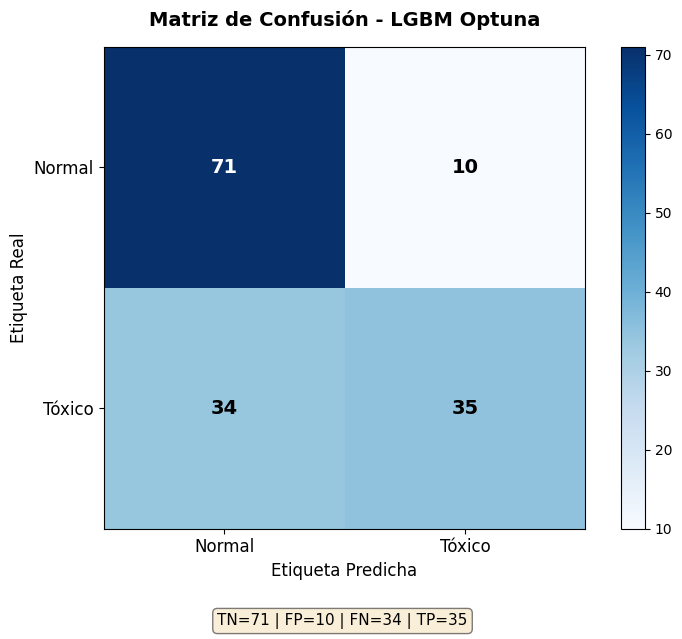


📊 ANÁLISIS:
   ✅ TN: 71 normales bien clasificados
   ✅ TP: 35 tóxicos bien clasificados
   ❌ FP: 10 normales marcados como tóxicos
   ❌ FN: 34 tóxicos que NO detectó

✅ Matriz guardada en: ../../reports/V_02/confusion_matrix_LGBM_Optuna.png


In [45]:
# MATRIZ DE CONFUSIÓN - LGBM OPTUNA
print("="*80)
print("📊 MATRIZ DE CONFUSIÓN - LGBM OPTUNA")
print("="*80)

cm_lgbm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm_lgbm.ravel()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_lgbm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)

clases = ['Normal', 'Tóxico']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(clases, fontsize=12)
ax.set_yticklabels(clases, fontsize=12)

thresh = cm_lgbm.max() / 2
for i in range(cm_lgbm.shape[0]):
    for j in range(cm_lgbm.shape[1]):
        ax.text(j, i, format(cm_lgbm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm_lgbm[i, j] > thresh else "black",
                fontsize=14, fontweight='bold')

ax.set_title('Matriz de Confusión - LGBM Optuna',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Etiqueta Real', fontsize=12)
ax.set_xlabel('Etiqueta Predicha', fontsize=12)

plt.figtext(0.5, -0.05,
            f'TN={tn} | FP={fp} | FN={fn} | TP={tp}',
            ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

os.makedirs('../../reports/V_02', exist_ok=True)
ruta_cm_lgbm_optuna = '../../reports/V_02/confusion_matrix_LGBM_Optuna.png'
plt.savefig(ruta_cm_lgbm_optuna, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 ANÁLISIS:")
print(f"   ✅ TN: {tn} normales bien clasificados")
print(f"   ✅ TP: {tp} tóxicos bien clasificados")
print(f"   ❌ FP: {fp} normales marcados como tóxicos")
print(f"   ❌ FN: {fn} tóxicos que NO detectó")
print(f"\n✅ Matriz guardada en: {ruta_cm_lgbm_optuna}")

In [47]:
# REGISTRAR LGBM OPTUNA EN MLFLOW
print("="*80)
print("📡 REGISTRANDO LGBM OPTUNA EN MLFLOW")
print("="*80)

with mlflow.start_run(run_name="LightGBM_Optuna_vectorizer_800"):

    # Parámetros del modelo
    mlflow.log_param("modelo", "LightGBM")
    mlflow.log_param("n_estimators", mejores_params_lgbm['n_estimators'])
    mlflow.log_param("learning_rate", mejores_params_lgbm['learning_rate'])
    mlflow.log_param("num_leaves", mejores_params_lgbm['num_leaves'])
    mlflow.log_param("max_depth", mejores_params_lgbm['max_depth'])
    mlflow.log_param("min_child_samples", mejores_params_lgbm['min_child_samples'])
    mlflow.log_param("subsample", mejores_params_lgbm['subsample'])
    mlflow.log_param("colsample_bytree", mejores_params_lgbm['colsample_bytree'])
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("early_stopping_rounds", 20)
    mlflow.log_param("optuna_trials", 50)

    # Parámetros del vectorizador
    mlflow.log_param("vectorizer", "TF-IDF")
    mlflow.log_param("max_features", 800)
    mlflow.log_param("ngram_range", "(1,2)")
    mlflow.log_param("min_df", 3)
    mlflow.log_param("max_df", 0.85)

    # ✅ Métricas con convención del equipo
    mlflow.log_metrics({
        "accuracy_train":  acc_train,
        "accuracy_test":   acc_test,
        "f1_train":        f1_train,
        "f1_test":         f1_test,
        "precision_test":  precision_score(y_test, y_pred_test, average=avg_method),
        "recall_test":     recall_score(y_test, y_pred_test, average=avg_method),
        "roc_auc_test":    roc_auc_score(y_test, y_proba_test),
        "overfitting_acc": acc_train - acc_test,
        "overfitting_f1":  f1_train - f1_test
    })

    # Tags
    mlflow.set_tag("developer", "PON_AQUI_TU_NOMBRE")
    mlflow.set_tag("model_type", "optuna")
    mlflow.set_tag("vectorizer", "TF-IDF")

    # Subir matriz de confusión como artefacto
    mlflow.log_artifact(ruta_cm_lgbm_optuna)

    # Guardar modelo
    mlflow.lightgbm.log_model(lgbm_optuna, "lightgbm_optuna_model")

    print(f"\n✅ Métricas registradas con convención del equipo")
    print(f"✅ Matriz de confusión subida como artefacto")
    print(f"✅ Modelo guardado")
    print(f"\n📊 RESUMEN REGISTRADO:")
    print(f"   accuracy_train:  {acc_train*100:.1f}%")
    print(f"   accuracy_test:   {acc_test*100:.1f}%")
    print(f"   f1_train:        {f1_train*100:.1f}%")
    print(f"   f1_test:         {f1_test*100:.1f}%")
    print(f"   precision_test:  {precision_score(y_test, y_pred_test, average=avg_method)*100:.1f}%")
    print(f"   recall_test:     {recall_score(y_test, y_pred_test, average=avg_method)*100:.1f}%")
    print(f"   roc_auc_test:    {roc_auc_score(y_test, y_proba_test)*100:.1f}%")
    print(f"   overfitting_acc: {(acc_train-acc_test)*100:.1f}%")
    print(f"   overfitting_f1:  {(f1_train-f1_test)*100:.1f}%")
    print(f"\n🔗 Ver en DagsHub:")
    print(f"   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow")

📡 REGISTRANDO LGBM OPTUNA EN MLFLOW


2026/05/13 21:48:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 21:48:52 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/13 21:49:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



✅ Métricas registradas con convención del equipo
✅ Matriz de confusión subida como artefacto
✅ Modelo guardado

📊 RESUMEN REGISTRADO:
   accuracy_train:  79.6%
   accuracy_test:   70.7%
   f1_train:        77.0%
   f1_test:         61.4%
   precision_test:  77.8%
   recall_test:     50.7%
   roc_auc_test:    76.4%
   overfitting_acc: 8.9%
   overfitting_f1:  15.6%

🔗 Ver en DagsHub:
   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow
🏃 View run LightGBM_Optuna_vectorizer_800 at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0/runs/f45691bee19943b297139d5e699e412e
🧪 View experiment at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0


In [56]:
from sklearn.naive_bayes import MultinomialNB

# OPTUNA - MULTINOMIAL NAIVE BAYES
print("="*80)
print("🔬 OPTUNA - MULTINOMIAL NAIVE BAYES")
print("="*80)

def objetivo_mnb(trial):
    """
    Función objetivo para Optuna con MultinomialNB.
    Solo optimizamos alpha (suavizado de Laplace).
    """

    # Optuna sugiere alpha
    alpha = trial.suggest_float('alpha', 0.001, 10.0, log=True)

    # Crear modelo
    modelo = MultinomialNB(alpha=alpha)

    try:
        # Entrenar
        modelo.fit(X_train_vec, y_train)

        # Evaluar en val
        y_pred_val = modelo.predict(X_val_vec)
        f1_val = f1_score(y_val, y_pred_val, average='binary')

        return f1_val

    except Exception as e:
        # Si falla por valores negativos devolvemos 0
        return 0.0

# Crear estudio
study_mnb = optuna.create_study(direction='maximize')

print(f"\n⏳ Ejecutando 50 trials...")
print(f"   Optimizando: F1-Score en val.csv\n")

study_mnb.optimize(objetivo_mnb, n_trials=50)

print(f"\n{'='*80}")
print(f"✅ OPTIMIZACIÓN COMPLETADA")
print(f"{'='*80}")
print(f"\n🏆 MEJORES PARÁMETROS:")
for param, valor in study_mnb.best_params.items():
    print(f"   {param}: {valor}")
print(f"\n🎯 MEJOR F1 en val.csv: {study_mnb.best_value:.4f} ({study_mnb.best_value*100:.1f}%)")

🔬 OPTUNA - MULTINOMIAL NAIVE BAYES

⏳ Ejecutando 50 trials...
   Optimizando: F1-Score en val.csv


✅ OPTIMIZACIÓN COMPLETADA

🏆 MEJORES PARÁMETROS:
   alpha: 9.53890855559009

🎯 MEJOR F1 en val.csv: 0.7246 (72.5%)


In [57]:
# ENTRENAR MNB CON MEJORES PARÁMETROS
print("="*80)
print("🤖 ENTRENANDO MNB CON MEJORES PARÁMETROS")
print("="*80)

mejores_params_mnb = study_mnb.best_params
print(f"\n📋 Parámetros:")
print(f"   alpha: {mejores_params_mnb['alpha']:.4f}")

# Crear modelo final
mnb_optuna = MultinomialNB(
    alpha=mejores_params_mnb['alpha']
)

print(f"\n⏳ Entrenando modelo final...")
mnb_optuna.fit(X_train_vec, y_train)
print(f"✅ Modelo entrenado correctamente")

# Predicciones
y_pred_train = mnb_optuna.predict(X_train_vec)
y_pred_test  = mnb_optuna.predict(X_test_vec)
y_proba_test = mnb_optuna.predict_proba(X_test_vec)[:, 1]

print(f"\n✅ Predicciones generadas")

🤖 ENTRENANDO MNB CON MEJORES PARÁMETROS

📋 Parámetros:
   alpha: 9.5389

⏳ Entrenando modelo final...
✅ Modelo entrenado correctamente

✅ Predicciones generadas


In [58]:
# MÉTRICAS MNB OPTIMIZADO CON OPTUNA
print("="*80)
print("📊 MÉTRICAS MNB OPTIMIZADO CON OPTUNA")
print("="*80)

avg_method = 'binary'

# Calcular métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred_test)
f1_train  = f1_score(y_train, y_pred_train, average=avg_method)
f1_test   = f1_score(y_test, y_pred_test, average=avg_method)

# Mostrar métricas
print(f"\n📊 MÉTRICAS:")
print(f"{'='*40}")
print(f"  Accuracy Train:   {acc_train*100:.1f}%")
print(f"  Accuracy Test:    {acc_test*100:.1f}%")
print(f"  Overfitting Acc:  {(acc_train-acc_test)*100:.1f}%")
print(f"{'='*40}")
print(f"  F1 Train:         {f1_train*100:.1f}%")
print(f"  F1 Test:          {f1_test*100:.1f}%")
print(f"  Overfitting F1:   {(f1_train-f1_test)*100:.1f}%")
print(f"{'='*40}")
print(f"  Precision Test:   {precision_score(y_test, y_pred_test, average=avg_method)*100:.1f}%")
print(f"  Recall Test:      {recall_score(y_test, y_pred_test, average=avg_method)*100:.1f}%")
print(f"  ROC-AUC Test:     {roc_auc_score(y_test, y_proba_test)*100:.1f}%")

# Verificar overfitting
print(f"\n{'='*40}")
if (acc_train - acc_test) < 0.05:
    print(f"✅ Overfitting CONTROLADO (< 5%)")
else:
    print(f"⚠️ Overfitting ALTO (> 5%)")

# Reporte completo
print(f"\n📋 REPORTE COMPLETO:")
print(classification_report(y_test, y_pred_test,
      target_names=['Normal', 'Tóxico']))

📊 MÉTRICAS MNB OPTIMIZADO CON OPTUNA

📊 MÉTRICAS:
  Accuracy Train:   86.6%
  Accuracy Test:    72.7%
  Overfitting Acc:  13.9%
  F1 Train:         86.9%
  F1 Test:          70.1%
  Overfitting F1:   16.9%
  Precision Test:   70.6%
  Recall Test:      69.6%
  ROC-AUC Test:     79.9%

⚠️ Overfitting ALTO (> 5%)

📋 REPORTE COMPLETO:
              precision    recall  f1-score   support

      Normal       0.74      0.75      0.75        81
      Tóxico       0.71      0.70      0.70        69

    accuracy                           0.73       150
   macro avg       0.72      0.72      0.72       150
weighted avg       0.73      0.73      0.73       150



📊 MATRIZ DE CONFUSIÓN - MNB OPTUNA


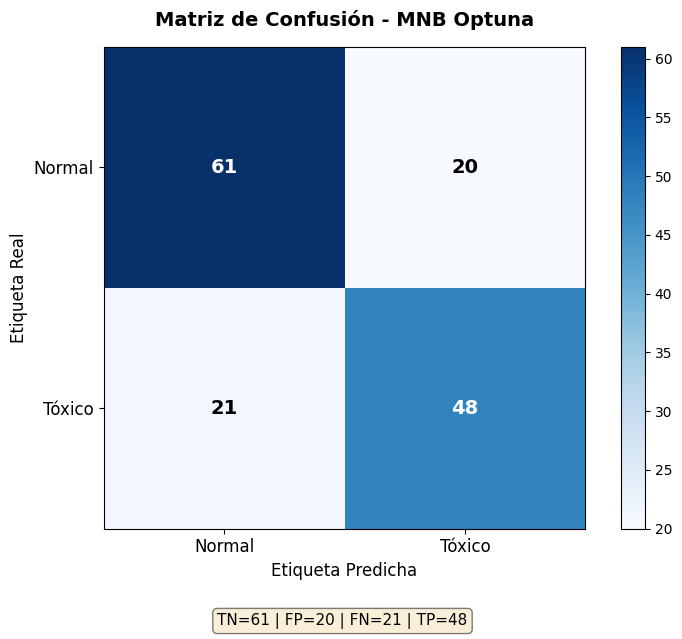


📊 ANÁLISIS:
   ✅ TN: 61 normales bien clasificados
   ✅ TP: 48 tóxicos bien clasificados
   ❌ FP: 20 normales marcados como tóxicos
   ❌ FN: 21 tóxicos que NO detectó

✅ Matriz guardada en: ../../reports/V_02/confusion_matrix_MNB_Optuna.png


In [59]:
# MATRIZ DE CONFUSIÓN - MNB OPTUNA
print("="*80)
print("📊 MATRIZ DE CONFUSIÓN - MNB OPTUNA")
print("="*80)

cm_mnb = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm_mnb.ravel()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_mnb, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)

clases = ['Normal', 'Tóxico']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(clases, fontsize=12)
ax.set_yticklabels(clases, fontsize=12)

thresh = cm_mnb.max() / 2
for i in range(cm_mnb.shape[0]):
    for j in range(cm_mnb.shape[1]):
        ax.text(j, i, format(cm_mnb[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm_mnb[i, j] > thresh else "black",
                fontsize=14, fontweight='bold')

ax.set_title('Matriz de Confusión - MNB Optuna',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Etiqueta Real', fontsize=12)
ax.set_xlabel('Etiqueta Predicha', fontsize=12)

plt.figtext(0.5, -0.05,
            f'TN={tn} | FP={fp} | FN={fn} | TP={tp}',
            ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

os.makedirs('../../reports/V_02', exist_ok=True)
ruta_cm_mnb = '../../reports/V_02/confusion_matrix_MNB_Optuna.png'
plt.savefig(ruta_cm_mnb, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 ANÁLISIS:")
print(f"   ✅ TN: {tn} normales bien clasificados")
print(f"   ✅ TP: {tp} tóxicos bien clasificados")
print(f"   ❌ FP: {fp} normales marcados como tóxicos")
print(f"   ❌ FN: {fn} tóxicos que NO detectó")
print(f"\n✅ Matriz guardada en: {ruta_cm_mnb}")

In [61]:
# REGISTRAR MNB OPTUNA EN MLFLOW
print("="*80)
print("📡 REGISTRANDO MNB OPTUNA EN MLFLOW")
print("="*80)

with mlflow.start_run(run_name="MultinomialNB_Optuna_TFIDF"):

    # Parámetros del modelo
    mlflow.log_param("modelo", "MultinomialNB")
    mlflow.log_param("alpha", mejores_params_mnb['alpha'])
    mlflow.log_param("optuna_trials", 50)

    # Parámetros del vectorizador
    mlflow.log_param("vectorizer", "TF-IDF")
    mlflow.log_param("max_features", 1000)
    mlflow.log_param("ngram_range", "(1,2)")
    mlflow.log_param("min_df", 5)
    mlflow.log_param("max_df", 0.85)

    # ✅ Métricas con convención del equipo
    mlflow.log_metrics({
        "accuracy_train":  acc_train,
        "accuracy_test":   acc_test,
        "f1_train":        f1_train,
        "f1_test":         f1_test,
        "precision_test":  precision_score(y_test, y_pred_test, average=avg_method),
        "recall_test":     recall_score(y_test, y_pred_test, average=avg_method),
        "roc_auc_test":    roc_auc_score(y_test, y_proba_test),
        "overfitting_acc": acc_train - acc_test,
        "overfitting_f1":  f1_train - f1_test
    })

    # Tags
    mlflow.set_tag("developer", "Gema")
    mlflow.set_tag("model_type", "optuna")
    mlflow.set_tag("vectorizer", "TF-IDF")

    # Subir matriz de confusión como artefacto
    mlflow.log_artifact(ruta_cm_mnb)

    # Guardar modelo
    mlflow.sklearn.log_model(mnb_optuna, "mnb_optuna_tfidf_model")

    print(f"\n✅ Métricas registradas con convención del equipo")
    print(f"✅ Matriz de confusión subida como artefacto")
    print(f"✅ Modelo guardado")
    print(f"\n📊 RESUMEN REGISTRADO:")
    print(f"   accuracy_train:  {acc_train*100:.1f}%")
    print(f"   accuracy_test:   {acc_test*100:.1f}%")
    print(f"   f1_train:        {f1_train*100:.1f}%")
    print(f"   f1_test:         {f1_test*100:.1f}%")
    print(f"   precision_test:  {precision_score(y_test, y_pred_test, average=avg_method)*100:.1f}%")
    print(f"   recall_test:     {recall_score(y_test, y_pred_test, average=avg_method)*100:.1f}%")
    print(f"   roc_auc_test:    {roc_auc_score(y_test, y_proba_test)*100:.1f}%")
    print(f"   overfitting_acc: {(acc_train-acc_test)*100:.1f}%")
    print(f"   overfitting_f1:  {(f1_train-f1_test)*100:.1f}%")
    print(f"\n🔗 Ver en DagsHub:")
    print(f"   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow")

📡 REGISTRANDO MNB OPTUNA EN MLFLOW


2026/05/13 23:00:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 23:00:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/13 23:00:48 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



✅ Métricas registradas con convención del equipo
✅ Matriz de confusión subida como artefacto
✅ Modelo guardado

📊 RESUMEN REGISTRADO:
   accuracy_train:  86.6%
   accuracy_test:   72.7%
   f1_train:        86.9%
   f1_test:         70.1%
   precision_test:  70.6%
   recall_test:     69.6%
   roc_auc_test:    79.9%
   overfitting_acc: 13.9%
   overfitting_f1:  16.9%

🔗 Ver en DagsHub:
   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow
🏃 View run MultinomialNB_Optuna_TFIDF at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0/runs/bc17f77b89a24c2788c6f0cdef2cec66
🧪 View experiment at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0
